# Conformal STL material assignment diagnostic

This notebook is a **diagnostic / visual test** for the new conformal STL material pipeline.

It checks three things:

1. `GridFIT3D(..., geometry_mode="conformal")` creates the new point-mask based geometry.
2. `SolverFIT3D` assigns **effective** material values (`eps`, `mu`, `sigma`) from the conformal masks.
3. The assigned values can be inspected visually on 2D slices.

The example uses the same STL pair as the existing 007 / 013 tests:

- `tests/stl/007_vacuum_cavity.stl`
- `tests/stl/007_lossymetal_shell.stl`

For the diagnostic plots, a **nontrivial background material** is intentionally chosen so that background, cavity, shell and interface regions are easier to distinguish visually.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

from scipy.constants import epsilon_0 as eps_0
from scipy.constants import mu_0 as mu_0

from wakis import GridFIT3D, SolverFIT3D

In [2]:
# ------------------------------------------------------------------
# Geometry and material setup
# ------------------------------------------------------------------
stl_dir = Path("..") / "tests" / "stl"
solid_cavity = stl_dir / "007_vacuum_cavity.stl"
solid_shell = stl_dir / "007_lossymetal_shell.stl"

stl_solids = {
    "cavity": str(solid_cavity),
    "shell": str(solid_shell),
}

# Diagnostic choice:
# use a nontrivial background so that background / cavity / shell /
# interface regions are easier to distinguish in the material plots.
background_material = [2.0, 1.5, 0.2]   # [eps_r, mu_r, sigma]

stl_materials = {
    "cavity": [1.0, 1.0, 0.0],
    "shell": [30.0, 1.0, 30.0],
}

# Bounds from the STL pair
import pyvista as pv
solids = pv.read(stl_solids["cavity"]) + pv.read(stl_solids["shell"])
xmin, xmax, ymin, ymax, zmin, zmax = solids.bounds

Nx, Ny, Nz = 60, 60, 140

print("Bounds:")
print(f"x: [{xmin:.6f}, {xmax:.6f}]")
print(f"y: [{ymin:.6f}, {ymax:.6f}]")
print(f"z: [{zmin:.6f}, {zmax:.6f}]")

Bounds:
x: [-0.260000, 0.260000]
y: [-0.260000, 0.260000]
z: [-0.250000, 0.550000]


In [3]:
# ------------------------------------------------------------------
# Build grid and solver using the conformal geometry path
# ------------------------------------------------------------------
grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    zmin,
    zmax,
    Nx,
    Ny,
    Nz,
    stl_solids=stl_solids,
    stl_materials=stl_materials,
    stl_method="voxelize_rectilinear",
    geometry_mode="conformal",
    subpixel_smoothing=False,
    stl_scale=1.0,
    stl_rotate=[0, 0, 0],
    stl_translate=[0, 0, 0],
    verbose=1,
)

solver = SolverFIT3D(
    grid=grid,
    bc_low=["pec", "pec", "pec"],
    bc_high=["pec", "pec", "pec"],
    use_stl=True,
    bg=background_material,
    verbose=1,
)

Generating grid with 504000 mesh cells...
Importing STL solids...
 * Marking grid points inside STL solid 'cavity'...
    * STL solid cavity: 120613 primal points, 117518 cell centers, and 117518 dual points marked inside the solid.
 * Marking grid points inside STL solid 'shell'...
    * STL solid shell: 61292 primal points, 54920 cell centers, and 54992 dual points marked inside the solid.
Total grid initialization time: 0.36331868171691895 s
Initializing Electromagnetic solver...
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
Calculating maximal stable timestep...
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 1.1317682266235352 s


## Basic sanity checks

The point-mask based conformal path should create

- primal point masks,
- cell-center masks, and
- dual point masks.

The solver should then convert those into effective `ieps`, `imu`, and `sigma` tensors.

In [4]:
print("Available primal masks:", list(grid.primal_point_masks.keys()))
print("Available dual masks:", list(grid.dual_point_masks.keys()))

print("Primal point mask shape (shell):", grid.primal_point_masks["shell"].shape)
print("Dual point mask shape   (shell):", grid.dual_point_masks["shell"].shape)
print("Stored cell-center mask shape    :", np.reshape(np.asarray(grid.grid["shell"]), (Nx, Ny, Nz)).shape)

assert grid.primal_point_masks["shell"].shape == (Nx + 1, Ny + 1, Nz + 1)
assert grid.dual_point_masks["shell"].shape == (Nx + 1, Ny + 1, Nz + 1)

for arr_name, arr in [
    ("ieps_x", solver.ieps.field_x),
    ("ieps_y", solver.ieps.field_y),
    ("ieps_z", solver.ieps.field_z),
    ("imu_x", solver.imu.field_x),
    ("imu_y", solver.imu.field_y),
    ("imu_z", solver.imu.field_z),
    ("sigma_x", solver.sigma.field_x),
    ("sigma_y", solver.sigma.field_y),
    ("sigma_z", solver.sigma.field_z),
]:
    assert np.all(np.isfinite(arr)), f"{arr_name} contains non-finite values"

print("All basic sanity checks passed.")

Available primal masks: ['cavity', 'shell']
Available dual masks: ['cavity', 'shell']
Primal point mask shape (shell): (61, 61, 141)
Dual point mask shape   (shell): (61, 61, 141)
Stored cell-center mask shape    : (60, 60, 140)
All basic sanity checks passed.


In [5]:
def safe_inverse(arr):
    arr = np.asarray(arr, dtype=float)

    out = np.empty_like(arr)
    out[:] = np.nan

    np.divide(
        1.0,
        arr,
        out=out,
        where=arr != 0.0,
    )

    return out


ieps_x = solver.ieps.to_matrix("x")
ieps_y = solver.ieps.to_matrix("y")
ieps_z = solver.ieps.to_matrix("z")

imu_x = solver.imu.to_matrix("x")
imu_y = solver.imu.to_matrix("y")
imu_z = solver.imu.to_matrix("z")

sigma_x = solver.sigma.to_matrix("x")
sigma_y = solver.sigma.to_matrix("y")
sigma_z = solver.sigma.to_matrix("z")


material_fields = {
    "eps": {
        "x": safe_inverse(ieps_x) / eps_0,
        "y": safe_inverse(ieps_y) / eps_0,
        "z": safe_inverse(ieps_z) / eps_0,
    },
    "mu": {
        "x": safe_inverse(imu_x) / mu_0,
        "y": safe_inverse(imu_y) / mu_0,
        "z": safe_inverse(imu_z) / mu_0,
    },
    "sigma": {
        "x": sigma_x,
        "y": sigma_y,
        "z": sigma_z,
    },
}

## Visual inspection of material assignment

The next widget plots 2D slices of the effective material values.

- `eps` and `sigma` correspond to **primary edges / dual faces**.
- `mu` corresponds to **dual edges / primary faces**.
- For each quantity, the three components `x`, `y`, `z` are plotted side by side.

The value ranges are taken separately for each component plot so that interface regions remain visible.

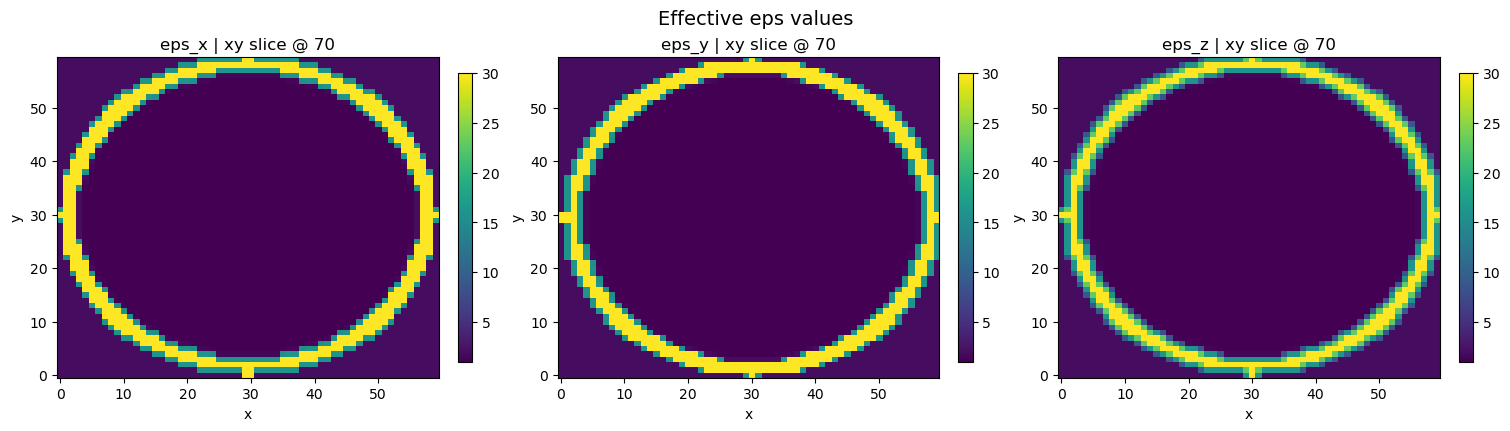

In [6]:
def get_slice(arr, plane, index):
    if plane == "xy":
        index = int(np.clip(index, 0, arr.shape[2] - 1))
        return arr[:, :, index].T
    if plane == "xz":
        index = int(np.clip(index, 0, arr.shape[1] - 1))
        return arr[:, index, :].T
    if plane == "yz":
        index = int(np.clip(index, 0, arr.shape[0] - 1))
        return arr[index, :, :].T
    raise ValueError(f"Unknown plane: {plane}")


def slice_shape_for_plane(arr, plane):
    if plane == "xy":
        return arr.shape[2]
    if plane == "xz":
        return arr.shape[1]
    if plane == "yz":
        return arr.shape[0]
    raise ValueError(f"Unknown plane: {plane}")


def plot_material_slices(quantity="eps", plane="xy", index=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

    comps = ["x", "y", "z"]
    for ax, comp in zip(axes, comps):
        arr = material_fields[quantity][comp]
        img = get_slice(arr, plane, index)
        im = ax.imshow(img, origin="lower", aspect="auto")
        ax.set_title(f"{quantity}_{comp} | {plane} slice @ {index}")
        ax.set_xlabel(plane[0])
        ax.set_ylabel(plane[1])
        plt.colorbar(im, ax=ax, shrink=0.9)

    fig.suptitle(f"Effective {quantity} values", fontsize=14)
    plt.show()


# Default example view
plot_material_slices(quantity="eps", plane="xy", index=Nz // 2)

In [ ]:
@interact(
    quantity=Dropdown(options=["eps", "mu", "sigma"], value="eps", description="quantity"),
    plane=Dropdown(options=["xy", "xz", "yz"], value="xy", description="plane"),
    index=IntSlider(min=0, max=Nz - 1, step=1, value=Nz // 2, description="index"),
)
def interactive_material_slices(quantity, plane, index):
    # keep the slider value valid even if the chosen plane has a different axis length
    if plane == "xy":
        max_index = Nz - 1
    elif plane == "xz":
        max_index = Ny - 1
    else:
        max_index = Nx - 1

    index = min(index, max_index)
    plot_material_slices(quantity=quantity, plane=plane, index=index)

interactive(children=(Dropdown(description='quantity', options=('eps', 'mu', 'sigma'), value='eps'), Dropdown(…